In [ ]:
import numpy as np
import pandas as pd

import scipy.stats as sts
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

#  Портфельная теория Марковица

В этом задании мы будем работать с данными по ценным бумагам. Мы немного поанализируем их и попробуем собрать оптимальный портфель.

- в таблице `stocks.csv` содержится информация об акциях нескольких компаний с $01.01.2014$ по $31.12.2023$ по дням.
- таблице `exchange_rates.csv` содержится информация о курсах валют _USD-RUB_, _EUR-RUB_ и _HKD-RUB_ за тот же период.

Подгрузим данные и посмотрим на них.

In [ ]:
df_stocks = pd.read_csv('https://raw.githubusercontent.com/hse-econ-data-science/andan2024/main/hw/data/stocks.csv')
print(df_stocks.shape)
df_stocks.head()

(17572, 8)


,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Тикер
0,29.12.2023,"192,53","193,90","194,40","191,73","42,67M","-0,54%",AAPL
1,28.12.2023,"193,58","194,14","194,66","193,17","33,83M","0,22%",AAPL
2,27.12.2023,"193,15","192,49","193,50","191,09","47,90M","0,05%",AAPL
3,26.12.2023,"193,05","193,61","193,89","192,83","28,81M","-0,28%",AAPL
4,22.12.2023,"193,60","195,18","195,41","192,97","37,15M","-0,55%",AAPL


In [ ]:
df_rates = pd.read_csv('https://raw.githubusercontent.com/hse-econ-data-science/andan2024/main/hw/data/exchange_rates.csv')
print(df_rates.shape)
df_rates.head()

(3652, 4)


,Дата,EUR_RUB,USD_RUB,HKD_RUB
0,01.01.2014,"45,189","32,855","4,237"
1,02.01.2014,"45,254","33,1","4,269"
2,03.01.2014,"45,114","33,2","4,282"
3,04.01.2014,"45,125","33,248","4,288"
4,05.01.2014,"45,228","33,255","4,289"


## 1 Причешем данные

Часто при загрузке данных из каких-либо источников, особенно если они разные, у вас будет возникать необходимость в их форматировании. Поэтому в этой части потренируемся корректировать переменные для последующей работы с ними.


__а) [2 балла]__ В колонке `'Дата'` лежат дни, в которые осуществлялась торговля акциями. Превратите её в формат `datetime` в обеих таблицах.

In [ ]:
df_stocks['Дата'] = pd.to_datetime(df_stocks['Дата'], format = '%d.%m.%Y')
df_rates['Дата'] = pd.to_datetime(df_rates['Дата'], format = '%d.%m.%Y')

__б) [5 баллов]__ Для продолжения работы необходимо перевести столбцы в числовой формат, однако они содержат некорректные символы, которые не позволят сделать это напрямую.

Допишите функцию, которая примет на вход тип данных `string` и:

- Уберет лишнюю точку, разделяющую тысячные разряды в числах (например, $2.024,01 \rightarrow 2024,01$)
- Заменит символ запятой, отделяющий десятичный разряд, на точку (например, $2024,01 \rightarrow 2024.01$)
- Уберет символы `%`, `'B'` (млрд), `'M'` (млн) и `'K'` (тыс)
- Затем изменит тип данных с `string` на `float`
- И домножит на $10^9$, если в исходном значении содержалась `'B'`, на $10^6$, если `'M'`, или на $10^3$, если `'K'`.

In [ ]:
def correct_values(value: str):

    value2 = value.replace(',', '.')
    value2 = value2[:value2.rfind('.')].replace('.', '') + value2[value2.rfind('.'):]
    value2 = value2.replace('%', '').replace('B', '').replace('M', '').replace('K', '')
    corrected_value = float(value2)

    if 'B' in value:
        corrected_value *= 10 ** 9
    elif 'M' in value:
        corrected_value *= 10 ** 6
    elif 'K' in value:
        corrected_value *= 10 ** 3

    return corrected_value

Примените данную функцию к столбцам `'Цена', 'Откр.', 'Макс.', 'Мин.', 'Объём', 'Изм. %'` таблицы `df_stocks` и к столбцам `'EUR_RUB', 'USD_RUB', 'HKD_RUB'` таблицы `df_rates`.

__Hint:__ Для этого можно использовать метод `map` библиотеки `pandas`. Важно также указать параметр `na_action='ignore'`, чтобы пустые значения не передавались в функцию `correct_values`, [(ссылка на документацию).](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html)

In [ ]:
col_stocks = ['Цена', 'Откр.', 'Макс.', 'Мин.', 'Объём', 'Изм. %']
col_rates = ['EUR_RUB', 'USD_RUB', 'HKD_RUB']
df_stocks[col_stocks] = df_stocks[col_stocks].applymap(correct_values, na_action = 'ignore')
df_rates[col_rates] = df_rates[col_rates].applymap(correct_values, na_action = 'ignore')

__в) [5 баллов]__ Поскольку акции компаний торгуются на разных биржах, цены также указаны в различных валютах.
Давайте приведем все к рублям, используя таблицу `df_rates`. Для этого важно знать, что данные по тикерам:

- `'AAPL'` и `'MSFT'` собраны в долларах `USD`
- `'MBGn'` и `'BMWG'` $-$ в евро `EUR`
- `'Tencent'` $-$ в Гонконгских долларах `HKD`
- по остальным $-$ в `RUB`

Давайте сначала объединим таблицы, выполнив операцию `left join` таблицы `df_stocks` с `df_rates` по столбцу `'Дата'`. Для этого будем использовать метод `merge`, [(ссылка на документацию).](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html)

In [ ]:
df_merged = df_stocks.merge(df_rates, how = 'left', on = 'Дата')

df_merged.head()

,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Тикер,EUR_RUB,USD_RUB,HKD_RUB
0,2023-12-29,192.53,193.90,194.40,191.73,42670000.0,-0.54,AAPL,98.596,90.36,11.429
1,2023-12-28,193.58,194.14,194.66,193.17,33830000.0,0.22,AAPL,97.919,89.36,11.325
2,2023-12-27,193.15,192.49,193.50,191.09,47900000.0,0.05,AAPL,101.779,91.27,11.731
3,2023-12-26,193.05,193.61,193.89,192.83,28810000.0,-0.28,AAPL,101.455,91.66,11.734
4,2023-12-22,193.60,195.18,195.41,192.97,37150000.0,-0.55,AAPL,101.467,92.00,11.791


 Затем преобразуем столбцы `'Цена', 'Откр.', 'Макс.', 'Мин.'`, умножив их на соответствующий данной акции курс.

In [ ]:
stocks_currency_dict = {
    "AAPL": "USD_RUB",
    "MSFT": "USD_RUB",
    "MBGn": "EUR_RUB",
    "BMWG": "EUR_RUB",
    "Tencent": "HKD_RUB",
}
col_rub = ['Цена', 'Откр.', 'Макс.', 'Мин.']
for ticker, curr_pair in stocks_currency_dict.items():
    usl = df_merged['Тикер'] == ticker
    df_merged.loc[usl, col_rub] = df_merged.loc[usl, col_rub].multiply(df_merged[curr_pair], axis = 0)
df_merged.head()

,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Тикер,EUR_RUB,USD_RUB,HKD_RUB
0,2023-12-29,17397.0108,17520.8040,17565.9840,17324.7228,42670000.0,-0.54,AAPL,98.596,90.36,11.429
1,2023-12-28,17298.3088,17348.3504,17394.8176,17261.6712,33830000.0,0.22,AAPL,97.919,89.36,11.325
2,2023-12-27,17628.8005,17568.5623,17660.7450,17440.7843,47900000.0,0.05,AAPL,101.779,91.27,11.731
3,2023-12-26,17694.9630,17746.2926,17771.9574,17674.7978,28810000.0,-0.28,AAPL,101.455,91.66,11.734
4,2023-12-22,17811.2000,17956.5600,17977.7200,17753.2400,37150000.0,-0.55,AAPL,101.467,92.00,11.791


Наконец, мы закончили с первичными преобразованиями и можем приступать к дальнейшему анализу.

## 2 Начало работы с данными

__а) [2 балла]__ Посмотрите наличие пропусков в данных таблицы `df_merged`. Информация по каким тикерам и за какой период отсутствует? Удалите строки с пропущенными данными.

In [ ]:
print('В таблице присутствуют пропуски в столбце "Объём":')
df_merged.isna().sum()

В таблице присутствуют пропуски в столбце "Объём":


Дата       0
Цена       0
Откр.      0
Макс.      0
Мин.       0
Объём      9
Изм. %     0
Тикер      0
EUR_RUB    0
USD_RUB    0
HKD_RUB    0
dtype: int64

In [ ]:
print('Строки, в которых присутствуют пропуски:')
display(df_merged[df_merged.isna().any(axis = 1)])
print('\n', 'Удалим эти строки')

Строки, в которых присутствуют пропуски:


,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Тикер,EUR_RUB,USD_RUB,HKD_RUB
1974,2016-02-27,7441.30030,7441.30030,7441.30030,7441.30030,NaN,300.12,AAPL,83.492,76.754,9.891
2800,2022-11-21,5195.40560,5214.67086,5238.90780,5191.05538,NaN,-0.65,BMWG,62.146,60.850,7.849
2944,2022-05-03,5745.28332,5618.13714,5745.28332,5593.71358,NaN,3.01,BMWG,71.834,70.960,8.697
2945,2022-05-02,5760.65508,5768.07478,5820.75465,5517.28892,NaN,-1.11,BMWG,74.197,73.440,9.006
7838,2022-11-21,3847.45886,3833.16528,3882.26062,3825.08630,NaN,-0.50,MBGn,62.146,60.850,7.849
7981,2022-05-04,4377.31124,4422.25716,4443.32556,4374.50212,NaN,-0.87,MBGn,70.228,66.300,8.425
7982,2022-05-03,4516.92192,4476.69488,4517.64026,4424.97440,NaN,1.06,MBGn,71.834,70.960,8.697
7988,2022-04-25,5181.59174,5173.47394,5227.86320,5110.96688,NaN,-1.39,MBGn,81.178,73.125,9.560
17313,2015-01-17,1037.63200,1037.63200,1037.63200,1037.63200,NaN,4.82,Tencent,75.166,64.942,8.368



 Удалим эти строки


In [ ]:
indexes_null = df_merged[df_merged.isna().any(axis = 1)].index.values
df_merged.drop(index = indexes_null, inplace = True)
df_merged.reset_index(drop = True, inplace = True)

__б) [2 балла]__ Какое количество уникальных тикеров содержится в таблице `df_stocks`?

In [ ]:
print(f"Уникальных тикеров {df_stocks['Тикер'].nunique()}, это: {df_stocks['Тикер'].unique()}")

Уникальных тикеров 7, это: ['AAPL' 'BMWG' 'GAZP' 'MBGn' 'MSFT' 'VTBR' 'Tencent']


__в) [2 балла]__  Для каких акций и в какой временной период была зафиксирована наибольшая разность между значениями `'Макс.'` и `'Мин.'` в рублях?

In [ ]:
max_min = np.argsort(-(df_merged['Макс.'] - df_merged['Мин.'])).values[:10]
display(df_merged.iloc[max_min][['Дата', 'Макс.', 'Мин.', 'Тикер']])
print('', 'У акций Microsoft (MSFT) зафиксирована наибольшая разность между значениями Макс и Мин', 'в основном в 2022 и 2023 годах в различные периоды и один раз в 2020.', sep = '\n')

,Дата,Макс.,Мин.,Тикер
10197,2023-07-18,33340.30200,31103.25300,MSFT
10546,2022-02-24,24807.60768,22820.71296,MSFT
10538,2022-03-08,36204.90000,34425.00000,MSFT
10568,2022-01-24,23408.10846,21748.87530,MSFT
10539,2022-03-07,41425.67000,39829.79000,MSFT
11038,2020-03-13,11756.77083,10218.82749,MSFT
10126,2023-10-26,32099.55480,30719.28240,MSFT
10140,2023-10-06,33051.00519,31756.83630,MSFT
10574,2022-01-13,24475.44288,23187.90400,MSFT
10170,2023-08-24,31588.14770,30353.00540,MSFT



У акций Microsoft (MSFT) зафиксирована наибольшая разность между значениями Макс и Мин
в основном в 2022 и 2023 годах в различные периоды и один раз в 2020.


__г) [2 балла]__  В какие периоды было продано/куплено акций на наибольшую сумму рублей. Какие это были акции?

__Hint__: Объем — это количество проданных/купленных акций

In [ ]:
max_sold = np.argsort(-(df_merged['Цена'].multiply(df_merged['Объём'])))[:10]
display(df_merged.iloc[max_sold][['Дата', 'Цена', 'Объём', 'Тикер']])
print('\n','Среди топ-10 по сумме проданных акций 9 мест - это компания Apple (AAPL), одно место - Microsoft (MSFT) в 2020-2023 годах в различные периоды')

,Дата,Цена,Объём,Тикер
843,2020-08-24,9394.19040,345940000.0,AAPL
844,2020-08-21,9302.87600,338050000.0,AAPL
834,2020-09-04,9121.47264,332610000.0,AAPL
859,2020-07-31,7906.91286,374300000.0,AAPL
456,2022-03-08,20073.60000,131150000.0,AAPL
10091,2023-12-15,33467.65075,78500000.0,MSFT
510,2021-12-17,12687.12162,195920000.0,AAPL
858,2020-08-03,7965.14810,308150000.0,AAPL
808,2020-10-13,9330.63390,262330000.0,AAPL
482,2022-01-28,13256.44324,179940000.0,AAPL



 Среди топ-10 по сумме проданных акций 9 мест - это компания Apple (AAPL), одно место - Microsoft (MSFT) в 2020-2023 годах в различные периоды


__д) [5 баллов]__  В столбике `'Изм. %'` лежат изменения стоимости ценных бумаг в процентах. При этом для каждой бумаги валюта своя.

Найдите 5 дат, в которые наблюдались наибольшие средние процентные изменения стоимости акций в абсолютном выражении.

__Hint:__ От изменения акций надо взять модуль, а затем посчитать среднее по тикерам для каждой даты.

In [ ]:
mean_izm = np.array([])
dates = df_merged['Дата'].unique()
for date in dates:
    sr = np.mean(abs(df_merged[df_merged['Дата'] == date]['Изм. %']))
    mean_izm = np.append(mean_izm, sr)
print('5 дат, в которые наблюдались наибольшие средние процентные изменения стоимости акций в абсолютном выражении:')
pd.DataFrame({'dates': dates[np.argsort(-mean_izm)[:5]]})

5 дат, в которые наблюдались наибольшие средние процентные изменения стоимости акций в абсолютном выражении:


,dates
0,2022-02-24
1,2016-02-29
2,2020-03-24
3,2020-03-12
4,2022-02-21


__е) [2 балла]__ Сохраните ответ в переменную `top_5_diff` в виде таблички:

| Дата     | Изм. % |
|----------|--------|
| 01/01/01 |   1   |
|    ...   |  ...  |
| 03/01/01 |   3   |

In [ ]:
top_5_diff = pd.DataFrame({'Дата': dates[np.argsort(-mean_izm)[:5]], 'Изм. %': -np.sort(-mean_izm)[:5]})
top_5_diff

,Дата,Изм. %
0,2022-02-24,13.081429
1,2016-02-29,11.840000
2,2020-03-24,10.795714
3,2020-03-12,10.615714
4,2022-02-21,9.128000


__ё) [5 баллов]__ Далее мы будем работать только со средними ценами, поэтому имеет смысл перевести таблицу из длинного формата в широкий

Было:

| Дата     | Цена | Тикер |
|----------|------|-------|
| 01/01/01 |  10  |   A   |
| 02/01/01 |  20  |   A   |
| 03/01/01 |  30  |   A   |
|   ...    | ...  |  ...  |
| 01/01/01 |  15  |   B   |
| 02/01/01 |  30  |   B   |
| 03/01/01 |  60  |   B   |
|   ...    | ...  |  ...  |

Станет:

| Дата     | Цена A | Цена B | ... |
|----------|--------|--------|-----|
| 01/01/14 |   10   |   15   | ... |
| 02/01/14 |   20   |   30   | ... |
| 03/01/14 |   30   |   60   | ... |
|   ...    |  ...   |  ...   | ... |


Это можно сделать по-разному, например, с помощью `pivot_table` ([ссылка](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html) на документацию)

In [ ]:
df = pd.pivot_table(df_merged, index = ['Дата'], columns = ['Тикер'])['Цена']
df.head()

Тикер,AAPL,BMWG,GAZP,MBGn,MSFT,Tencent,VTBR
Дата,,,,,,,
2014-01-02,653.72500,3780.51916,NaN,2789.90910,1229.99600,418.02048,NaN
2014-01-03,641.42400,3788.67372,NaN,2784.88722,1225.41200,410.55816,NaN
2014-01-06,645.27030,3756.04441,135.47,2785.23886,1199.87730,411.98177,0.04846
2014-01-07,639.27060,3770.02665,NaN,2815.67520,1206.62740,409.79112,NaN
2014-01-08,643.96557,3803.54355,137.33,2801.87619,1186.40952,416.51786,0.04791


__ж) [5 баллов]__  Для всех тикеров из таблички `df` постройти картинки с динамикой цен во времени, а также нистограммы цен. Дайте ответы на вопросы:

- Распределение стоимости акций похоже на нормальное?
- Что происходило с финансовыми рынками в течение последних $10$ лет? Они росли? Они падали? Видно ли, что были кризисы?

__Ответ:__ Распределение стоимостей акций не похоже на нормальное (гистограммы не выглядят как "колокол", скорее как несколько холмиков)

Если смотреть на долгосрочный тренд, все акции кроме GAZP и VTBR выросли за последние 10 лет. Посмотрев на колебания цен акций Газпома и ВТБ поближе, видно, что Газпром почти не увеличился в цене за 10 лет, однако наблюдаются скачки цен в рассматриваемом периоде; ВТБ же вообще почти не отличается от 0 (среднее значение цен VTBR = 0.046)

Сильно выделятся кризис 2022 года, когда по ПоНятНым причинам финансовый рынок обвалился; сильнее всего зафиксировано падение самых дорогих акций (Apple, Microsoft), они же сейчас быстрее растут. Однако акции Газпрома как упали в 2022 году до уровня 2014 г., так там и остаются.





In [ ]:
np.mean(df['VTBR'])

0.046223178186176585

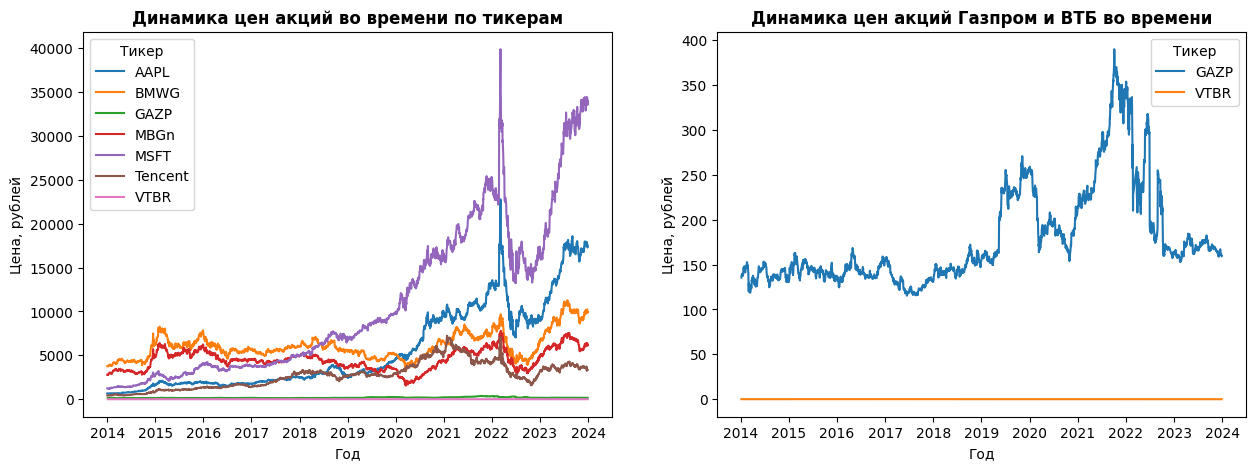

In [ ]:
# динамика цен во времени
fig = plt.figure(figsize = (15, 5))
gr1 = gridspec.GridSpec(1, 2)
axs1 = plt.subplot(gr1[0, 0])
axs1 = sns.lineplot(df, dashes = False)
axs1.legend(title = 'Тикер')
axs1.set_title('Динамика цен акций во времени по тикерам', fontweight = 'heavy')
axs1.set_xlabel('Год')
axs1.set_ylabel('Цена, рублей')

axs2 = plt.subplot(gr1[0, 1])
axs2 = sns.lineplot(df[['GAZP', 'VTBR']], dashes = False)
axs2.set_title('Динамика цен акций Газпром и ВТБ во времени', fontweight = 'heavy')
axs2.set_xlabel('Год')
axs2.set_ylabel('Цена, рублей')
plt.show()

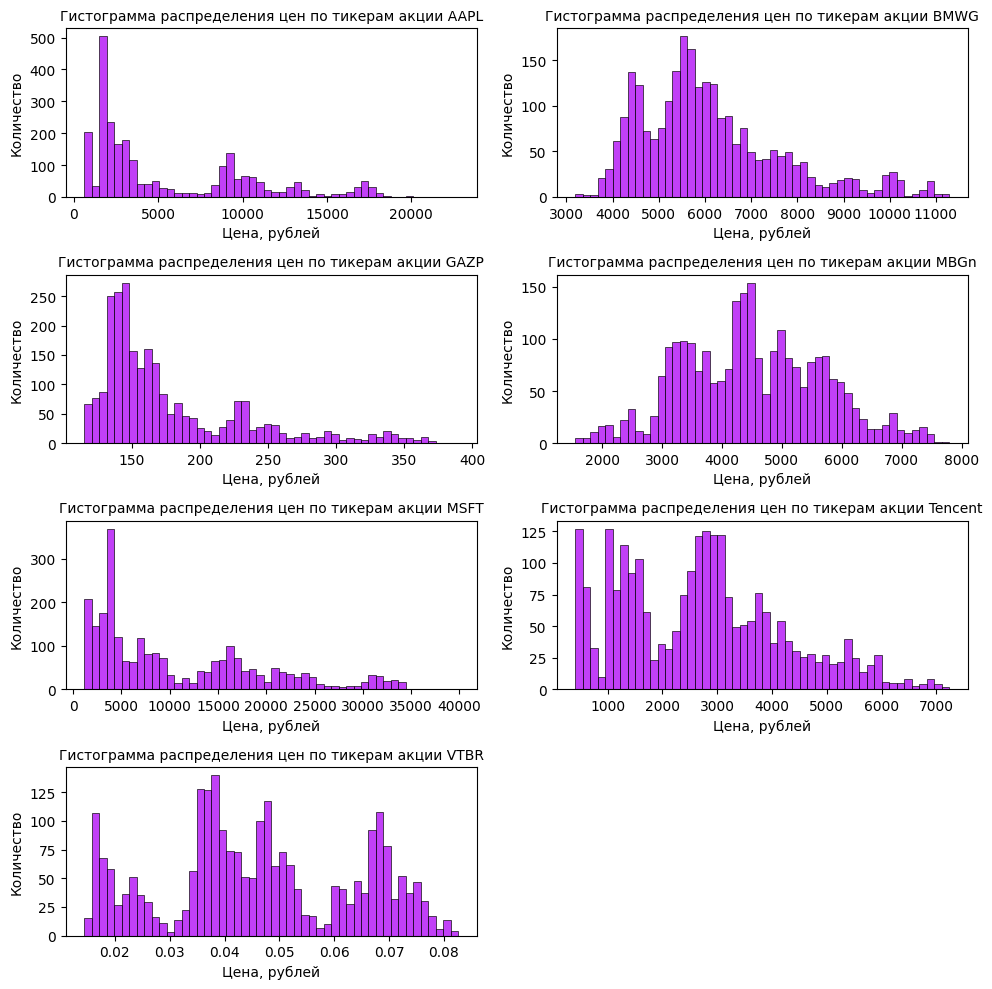

In [ ]:
# гистограммы цен
import itertools
fig = plt.figure(figsize = (10, 10))
gr = gridspec.GridSpec(4, 2)
shares = df.columns.values
for share, grd in zip(shares, itertools.product([0, 1, 2, 3], [0, 1])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.histplot(df[share], bins = 50, color = '#AD00F5')
    ax.set_title(f'Гистограмма распределения цен по тикерам акции {share}', fontsize = 10)
    ax.set_xlabel('Цена, рублей')
    ax.set_ylabel('Количество')
fig.tight_layout()
plt.show()

Финансовые продукты описываются двумя характеристикам – __доходностью__ и __риском.__ Доходность – это процентное изменение стоимости за некоторый промежуток времени:

$$
R_t = \left( \frac{P_t}{P_{t-1}} - 1 \right) \cdot 100\%.
$$

Под риском обычно имеют в виду стандартное отклонение.


__з) [5 баллов]__  Рассчитайте процентное изменение цены акций в рублях ото дня ко дню для `df`. Полученную таблицу доходностей сохраните в переменную `df_pct_change`.

__Hint__: С этим поможет метод `pct_change()`, [(ссылка на документацию).](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pct_change.html)

In [ ]:
df_pct_change = df.pct_change() * 100
df_pct_change.head()

Тикер,AAPL,BMWG,GAZP,MBGn,MSFT,Tencent,VTBR
Дата,,,,,,,
2014-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-03,-1.881678,0.215699,NaN,-0.180002,-0.372684,-1.785157,NaN
2014-01-06,0.599650,-0.861233,NaN,0.012627,-2.083764,0.346750,NaN
2014-01-07,-0.929796,0.372260,0.000000,1.092773,0.562566,-0.531735,0.000000
2014-01-08,0.734426,0.889036,1.372998,-0.490078,-1.675569,1.641505,-1.134957


__и) [5 баллов]__  Для всех тикеров из таблички `df_pct_change` постройти картинки с динамикой доходностей, гистограмму доходностей и ящики с усами. Ответьте на следующие вопроcы:

- Имеют ли доходности по акциям нормальное распределение?
- Видно ли по ящику с усами, что в данных довольно много выбросов?

__Ответ:__ доходности каждой акции очень похожи на нормальное распределение с матожиданием примерно в 0.

По ящику с усами видно большое количество выбросов; основная масса значений доходностей находится около нуля, при этом много кружочков выше и ниже "ящика", которые как раз показывают выбросы.

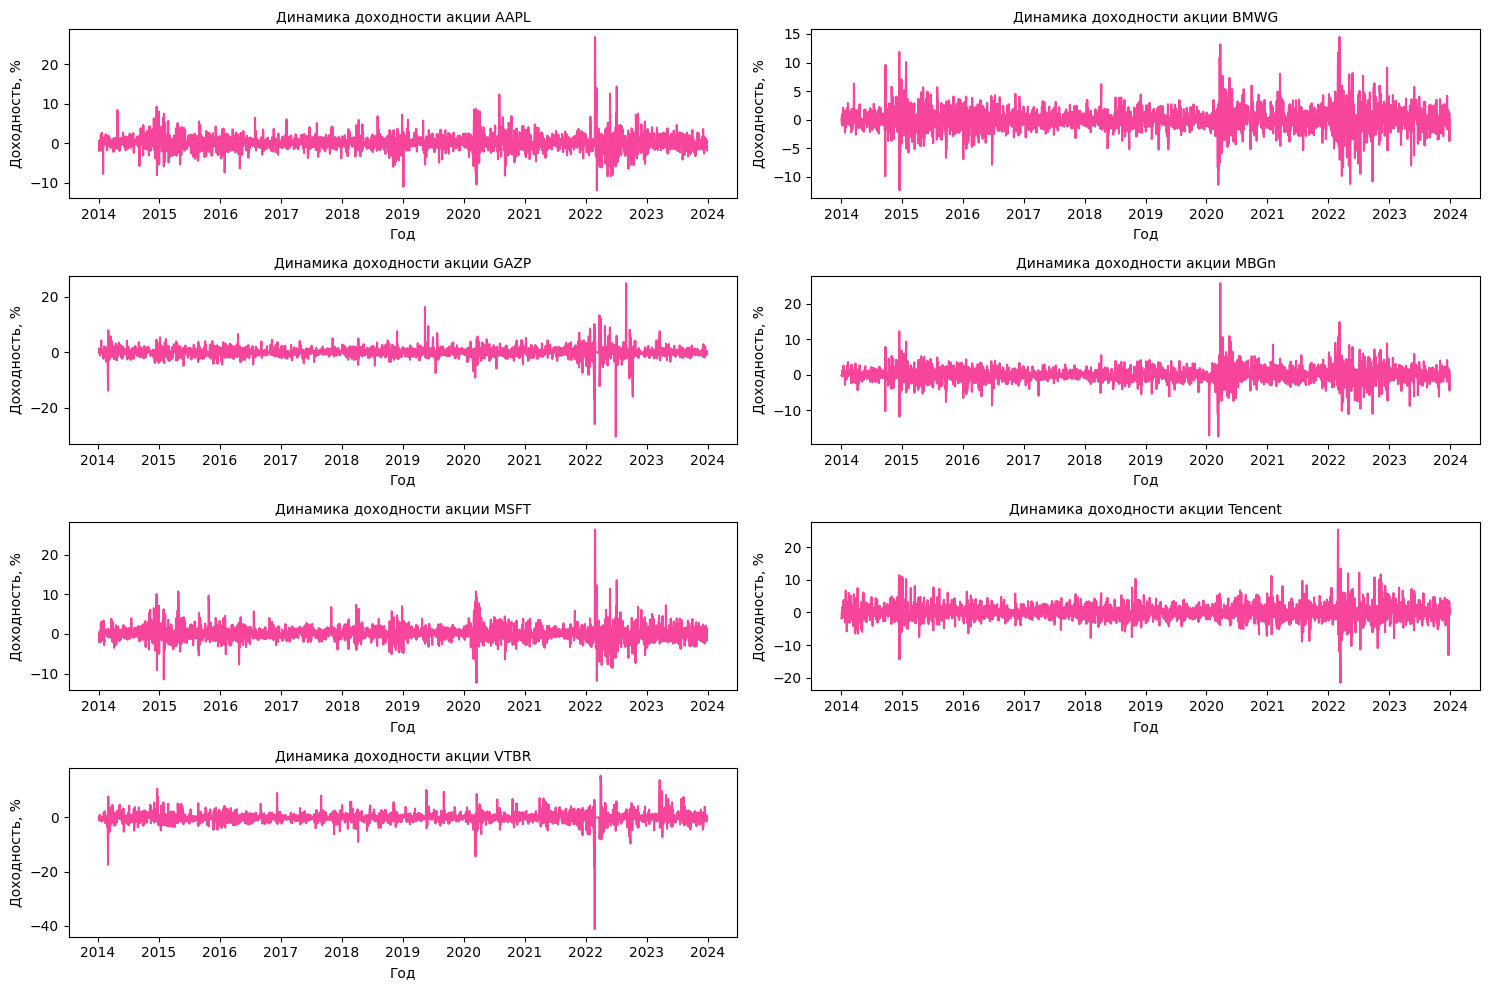

In [ ]:
# динамика доходностей
fig2 = plt.figure(figsize = (15, 10))
gr2 = gridspec.GridSpec(4, 2)
shares2 = df_pct_change.columns.values
for share, grd in zip(shares2, itertools.product([0, 1, 2, 3], [0, 1])):
    axs = plt.subplot(gr2[grd[0], grd[1]])
    axs = sns.lineplot(df_pct_change[share], dashes = False, color = '#f8459c')
    axs.set_title(f'Динамика доходности акции {share}', fontsize = 10)
    axs.set_xlabel('Год')
    axs.set_ylabel('Доходность, %')
fig2.tight_layout()
plt.show()

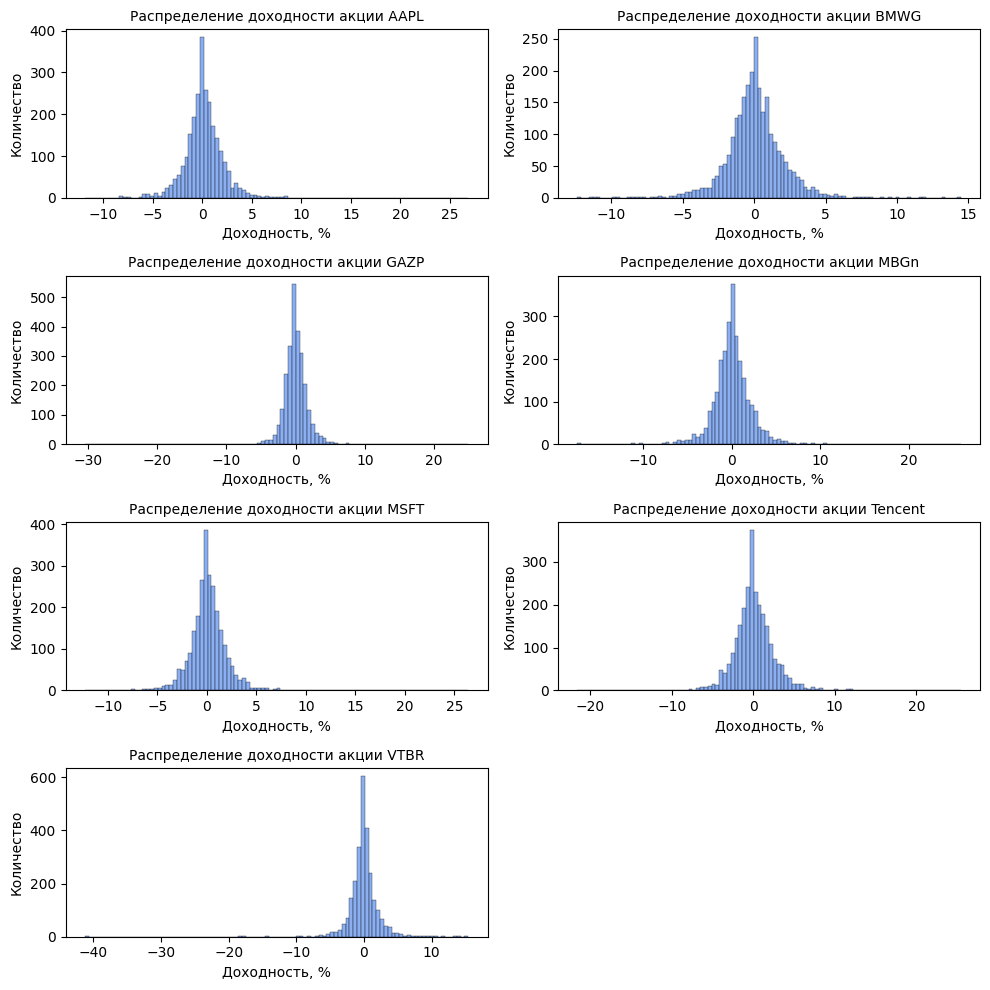

In [ ]:
# гистограмма доходностей
fig3 = plt.figure(figsize = (10, 10))
gr3 = gridspec.GridSpec(4, 2)
for share, grd in zip(shares2, itertools.product([0, 1, 2, 3], [0, 1])):
    axs = plt.subplot(gr3[grd[0], grd[1]])
    axs = sns.histplot(df_pct_change[share], color = '#6495ED', bins = 100)
    axs.set_title(f'Распределение доходности акции {share}', fontsize = 10)
    axs.set_xlabel('Доходность, %')
    axs.set_ylabel('Количество')
fig3.tight_layout()
plt.show()

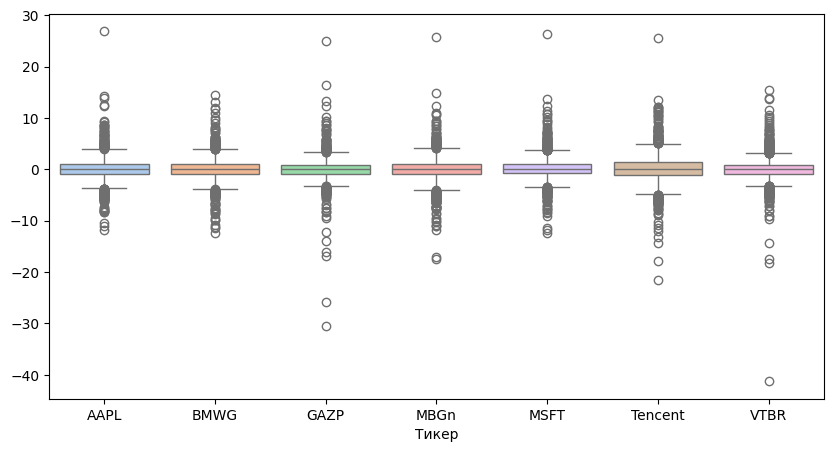

In [ ]:
figg = plt.figure(figsize = (10, 5))
sns.boxplot(df_pct_change, palette = 'pastel')
plt.show()

__к) [5 баллов]__  В пункте __д)__ мы нашли даты, в которые наблюдались наибольшие измения стоимости ценых бумаг. При расчётах мы проигнорировали колебания курсов валют.

Давайте посмотрим, каким бы было колебание цен акций в абсолютном выражении для дат из таблички `top_5_diff`, если бы мы учли изменения курсов валют.

В таблице `df_pct_change` все доходности измерены в рублях. Посчитайте для этой таблицы построчное среднее для абсолютных значений изменений.

In [ ]:
diff_rub = pd.DataFrame(np.mean(abs(df_pct_change), axis = 1))
diff_rub.head()

,0
Дата,
2014-01-02,NaN
2014-01-03,0.887044
2014-01-06,0.780805
2014-01-07,0.498447
2014-01-08,1.134081


Оставьте только те даты, которые встречаются в `top_5_diff`, и добавить их в качестве нового столбца `'Изм. (RUB) %'`

__Hint__: Чтобы выделить список необходимых дат из таблички `top_5_diff`, можно воспользоваться методом `to_list()` применительно к столбцу `'Дата'`. Такой список можно дальше использовать при обращении к строкам в `'[...]'`.

In [ ]:
top_5_diff['Изм. (RUB) %'] = diff_rub.loc[top_5_diff['Дата'].values].values

top_5_diff

,Дата,Изм. %,Изм. (RUB) %
0,2022-02-24,13.081429,12.677837
1,2016-02-29,11.840000,1.631587
2,2020-03-24,10.795714,9.703503
3,2020-03-12,10.615714,9.195150
4,2022-02-21,9.128000,5.438385


__л) [2 балла]__  Проинтерпретируете уменьшение/увеличение процентного изменения стоимости акций при пересчете по курсу в рубли.

__Ответ:__ Как видно на графиках ниже, в выделенные выше периоды рубль падал, и все валюты стоили дороже. При этом, предположу, что цены на акции в долларовом выражении снизились (по крайней мере в 2022 году было именно так). Соответственно, снижение стоимости в долларах частично нивелирируется снижением стоимости рубля, и в рублях снижение цен не такое большое.

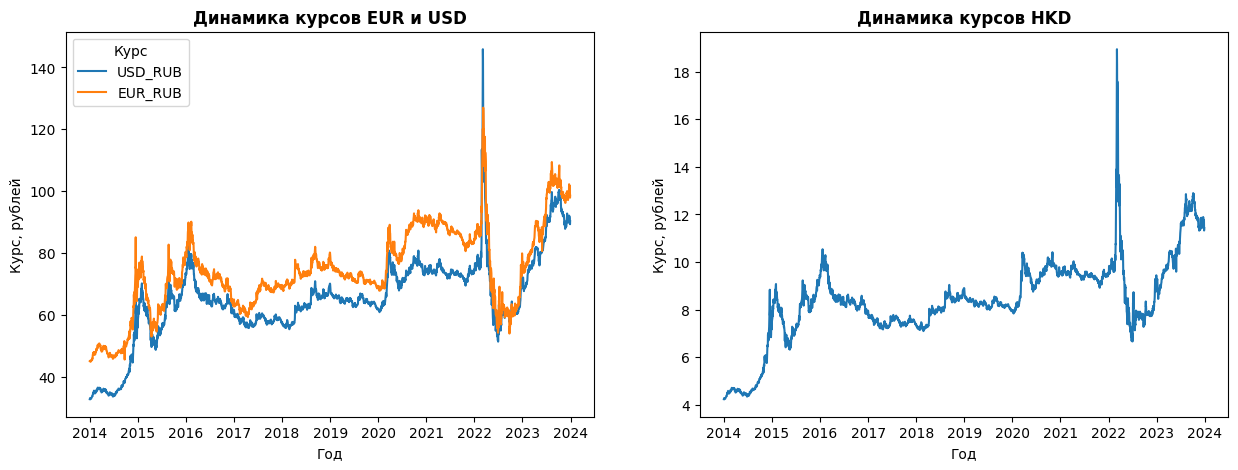

In [ ]:
fig11 = plt.figure(figsize = (15, 5))
grid1 = gridspec.GridSpec(1, 2)
axx1 = plt.subplot(grid1[0, 0])
axx1 = plt.plot('Дата', 'USD_RUB', data = df_rates, label = 'USD_RUB')
plt.plot('Дата', 'EUR_RUB', data = df_rates, label = 'EUR_RUB')
plt.title('Динамика курсов EUR и USD', fontweight = 'heavy')
plt.xlabel('Год')
plt.ylabel('Курс, рублей')
plt.legend(title = 'Курс')

axx2 = plt.subplot(grid1[0, 1])
axx2 = plt.plot('Дата', 'HKD_RUB', data = df_rates)
plt.title('Динамика курсов HKD', fontweight = 'heavy')
plt.xlabel('Год')
plt.ylabel('Курс, рублей')
plt.show()

## 3 Составляем портфель


Финансовые продукты описываются двумя характеристиками: __доходностью__ и __риском__.

Доходность — это процентное изменение стоимости за некоторый промежуток времени. Под риском, как правило, понимается стандартное отклонение доходности акций.

Однако когда речь идет о нескольких акциях в портфеле, то необходимо учитывать, как связана динамика цен на эти акции: падение доходности одной из акций может быть компенсировано ростом другой. Такой портфель будет предпочтительнее, поскольку предлагает меньшие риски для инвестора.

Осталось найти то самое сладкое сочетание активов... Для поиска оптимальных весов активов в портфеле обычно решается __задача оптимизации.__

Мы поступим проще:

- Будем рассматривать портфель, состоящий всего из 2 тикеров: `'AAPL'` и `'Tencent'`.
- Наилучшее сочетание весов будем искать неоптимальным способом, тупо перебирая различные варианты.

Пусть мы вкладываем долю нашего бюджета $w$ в первую ценную бумагу, а долю $(1 - w)$ во вторую. Тогда ожидаемая доходность порфеля составит

$$
\mathbb{E}(R) = w \cdot \mathbb{E}(R_1)  + (1 - w) \cdot \mathbb{E}(R_2).
$$

Дисперсия портфеля будет равна

$$
\text{Var}(R) = w^2 \cdot \text{Var}(R_1)  + (1 - w)^2 \cdot \text{Var}(R_2) + 2 \cdot w \cdot \text{Cov}(R_1, R_2).
$$

Ковариацию, по её определению, можно переписать как

$$
\text{Cov}(R_1, R_2) = \text{Corr}(R_1, R_2) \cdot \sigma(R_1) \cdot \sigma(R_2),
$$

где $\sigma(R_i) = \sqrt{ \text{Var}(R_i)}$.


Для начала создадим веса, которые будем рассматривать.

__а) [2 балла]__ С помощью функции `np.arange()` создайте `array` от $0$ до $1$ с шагом $0.01$ [(ссылка на документацию).](https://numpy.org/doc/stable/reference/generated/numpy.arange.html)

In [ ]:
w = np.arange(0, 1, 0.01)

Теперь запишем необходимые характеристики акций в соответствующие переменные:

__б) [3 балла]__ В переменные `r1` и `r2` сохраните среднюю доходность акций `'AAPL'` и `'Tencent'` из `df_pct_change`. Убедитесь, что доходности представлены не в процентах, а в виде чисел. Например не $10\%$, а $0.1$.

Кроме того, поскольку стандартной мерой доходности является годовая доходность, преобразуем среднюю ежедневную доходность в годовую, используя формулу сложного процента для полученных значений:

$$
r_{\text{год}} = (1 + r_{\text{день}})^{252} - 1,
$$

где:
- $r_{\text{год}}$ - ожидаемая годовая доходность,
- $r_{\text{день}}$ - средняя ежедневная доходность,
- $252$ - количество торговых дней в году (для большинства финансовых рынков).

In [ ]:
r1 = (1 + np.mean(df_pct_change['AAPL'] / 100)) ** 252 - 1
r2 = (1 + np.mean(df_pct_change['Tencent'] / 100)) ** 252 - 1

__в) [3 балла]__ Аналогично сохраните стандартные отклонения доходности этих акций в `sd1` и `sd2`. Преобразуйте эти значения из дневных в годовые:

$$
\sigma_{\text{год}} = \sigma_{\text{день}} \times \sqrt{252}
$$

Где:
- $\sigma_{\text{год}}$ - годовая волатильность,
- $\sigma_{\text{день}}$ - ежедневная волатильность,
- $252$ - количество торговых дней в году (для большинства финансовых рынков).

Эта формула основана на предположении, что ежедневные доходности распределены независимо и одинаково. В реальности рыночные условия могут влиять на точность этого преобразования, но это общепринятый метод для оценки годовой волатильности на основе ежедневных данных.

In [ ]:
sd1 = np.std(df_pct_change['AAPL'] / 100) * 252 ** 0.5
sd2 = np.std(df_pct_change['Tencent'] / 100) * 252 ** 0.5

__в) [1 балл]__ В переменную `rho` сохраните корреляцию между акциями.

In [ ]:
rho = df_pct_change.corr().loc['AAPL', 'Tencent']

Теперь посчитаем доходность и волатильность портфеля, используя соответствующие формулы

In [ ]:
r_p2 = w * r1 +(1 - w) * r2
sd_p2 = np.sqrt(w**2 * sd1**2 + (1 - w)**2 * sd2**2 + 2 * w * (1 - w) * rho * sd1 * sd2)

__г) [5 баллов]__ Постройте линейный график в осях (`sd_p2`, `r_p2`)

__Hint:__ Можно сделать с помощью `plt.plot(x, y)`

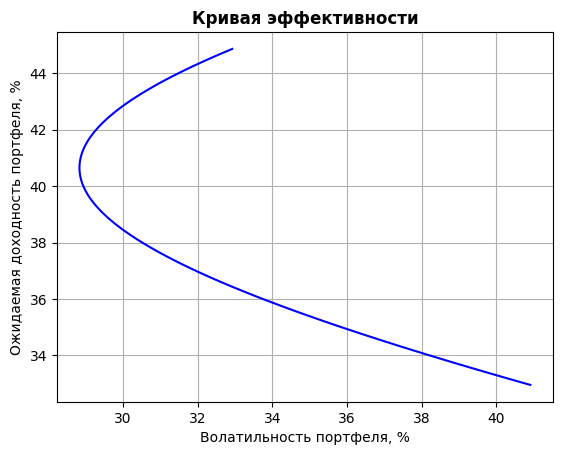

In [ ]:
plt.plot(sd_p2 * 100, r_p2 * 100, color = 'blue')
plt.title('Кривая эффективности', fontweight = 'heavy')
plt.ylabel('Ожидаемая доходность портфеля, %')
plt.xlabel('Волатильность портфеля, %')
plt.grid(True)
plt.show()

Получившаяся у вас картинка должна быть похожа на такую:

<center>
<img src="https://investprofit.info/wp-content/uploads/2018/08/Frontier1.png" height="450">
</center>

В портфельной теории Марковица эта кривая называется эффективной границей (или кривой эффективностию). Её можно поделить на три зоны:

- **Эффективная граница (Efficient Frontier)** — это часть кривой, которая лежит выше портфеля с минимальной дисперсией (риском). Портфели на этом участке предлагают наилучшее сочетание риска и доходности. Другими словами, для любого данного уровня риска, портфели на эффективной границе предлагают максимальную возможную доходность.
- **Портфели ниже эффективной границы** считаются неэффективными, так как для того же уровня риска можно добиться большей доходности.
- **Портфели выше эффективной границы** обычно не существуют, так как они предполагали бы получение более высокой доходности при том же уровне риска.

Найдем портфель с минимальной дисперсией (риском).

__д) [3 балла]__ Для этого сначала создадим табличку со столбцами `'Вес'`, `'Риск'` и `'Доходность'` (содержащими `w`, `sd_p2` и `r_p2` соответственно)

In [ ]:
df_r = pd.DataFrame({'Вес': w, 'Риск': sd_p2, 'Доходность': r_p2})

__е) [3 балла]__ Теперь найдем портфель с минимальным риском и запишем его в переменную `min_sd_p`, а само значение минимального риска в `min_sd`

In [ ]:
min_sd = min(df_r['Риск'])
min_sd_p = df_r[df_r['Риск'] == min_sd]

__ж) [3 балла]__ Выберем множество эффективных портфелей из `df_r`, тех, чья доходность и риск выше, чем у `min_sd_p` и сохраним их в `df_eff_p`

In [ ]:
eff = (df_r['Доходность'] > min_sd_p['Доходность'].iloc[0]) & (df_r['Риск'] > min_sd)
df_eff_p = df_r[eff]
df_eff_p.head()

,Вес,Риск,Доходность
65,0.65,0.288395,0.407731
66,0.66,0.288505,0.408934
67,0.67,0.288686,0.410137
68,0.68,0.288938,0.411340
69,0.69,0.289261,0.412543


__з) [3 балла]__ А теперь на основе `df_eff_p` построим эффективную границу, о которой шла речь раньше (часть кривой выше портфеля с наименьшей волатильностью)

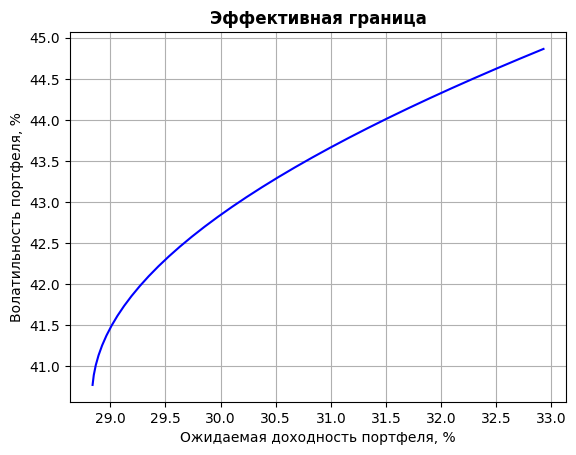

In [ ]:
plt.plot(df_eff_p['Риск'] * 100, df_eff_p['Доходность'] * 100, color = 'blue')
plt.title('Эффективная граница', fontweight = 'heavy')
plt.xlabel('Ожидаемая доходность портфеля, %')
plt.ylabel('Волатильность портфеля, %')
plt.grid(True)
plt.show()

Выше мы говорили, что для поиска оптимального портфеля необходимо решать задачу оптимизации. Целевую функцию для её решения можно определить по-разному. Выше мы занимались минимизацией риска и нашли `min_sd_p`.

Кроме минимизации риска можно попытаться максимизировать **коэффициент Шарпа.** Он рассчитывается по формуле

$$
SR = \frac{r_{p} - r_{f}}{\sigma_{p}},
$$

где $r_{p}$  —  ожидаемая доходность портфеля, $r_{f}$  —  безрисковая ставка доходности, $\sigma_{p}$ — стандартное отклонение доходности портфеля.

Коэффициент Шарпа отражает премию за принятый риск. Любая инвестиционная стратегия, демонстрирующая более крутой наклон кривой Шарпа, предлагает более высокую ожидаемую доходность для данного уровня риска. Следовательно, более высокий коэффициент Шарпа всегда предпочтительнее, независимо от того, какой уровень риска вы готовы принять.

В качестве безрисковой ставки доходности выберем доходность российских государственных облигаций сроком 10 лет (можно посмотреть [тут](https://cbr.ru/hd_base/zcyc_params/))

In [ ]:
r_f = 11.8/100

__и) [3 балла]__ Теперь у нас есть возможность рассчитать коэффициент Шарпа для кадждого портфеля в `df_r`. Для этого необходимо вычесть из доходности портфеля безрисковую ставку (`r_f`) и разделить на волатильность (риск) портфеля. Сохраните полученные значения в столбец `'Sharp'` таблицы `df_r`

In [ ]:
df_r['Sharp'] = (df_r['Доходность'] - r_f) / df_r['Риск']

__и) [3 балла]__ Определите портфель с максимальным коэффициентом Шарпа, сохраните его в переменную `max_sharp_p`, а значение самого коэффициента - в переменную `max_sharp`

In [ ]:
max_sharp = max(df_r['Sharp'])
max_sharp_p = df_r[df_r['Sharp'] == max_sharp]
max_sharp_p

,Вес,Риск,Доходность,Sharp
81,0.81,0.298541,0.426981,1.03497


Рассмотрим прямую в осях (Риск - Доходность), выраженную формулой

$$ r = max\_sharp \cdot \sigma + r_f $$

Для того, чтобы ее провести, нам необходимо задать хотя бы 2 точки. Чтобы построенный график хорошо выглядел, рассмотрим $\sigma$, равную:

1. наименьшему значению риска портфелей на эффективной кривой (`min_sd`)
2. значению риска, соответствующего портфелю с наибольшим значением коэффициента Шарпа (из `max_sharp_p`)

__к) [3 балла]__ В переменную `sigma` сохраните `numpy.array` с двумя перечисленными выше значениями

In [ ]:
sigma = np.array([min_sd, max_sharp_p['Риск'].iloc[0]])
sigma

array([0.28835674, 0.29854073])

__л) [3 балла]__ В переменную `r` сохраните значения доходности, находящиеся на указанной прямой, для значений риска из `sigma` (необходимо использовать формулу прямой)

In [ ]:
r = max_sharp * sigma + r_f
r

array([0.41644072, 0.42698085])

__м) [5 баллов]__ Теперь построим эффективную границу, что мы уже делали ранее, и проведем указанную прямую (вернее ее часть).

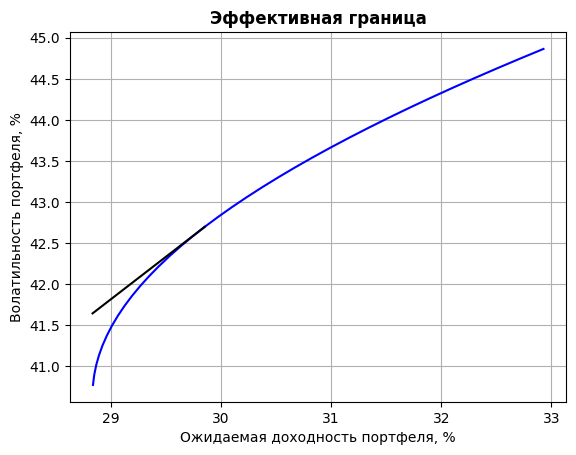

In [ ]:
plt.plot(df_eff_p['Риск'] * 100, df_eff_p['Доходность'] * 100, color = 'blue')
plt.plot(sigma * 100, r * 100, color = 'black')
plt.title('Эффективная граница', fontweight = 'heavy')
plt.xlabel('Ожидаемая доходность портфеля, %')
plt.ylabel('Волатильность портфеля, %')
plt.grid(True)
plt.show()

Полученная прямая является касательной к эффективной кривой, а точка ее касания представляет собой так называемый тангенциальный портфель.

Каждая точка на прямой Шарпа представляет собой портфель, состоящий из комбинации безрискового актива (в нашем случае, государственных облигаций) и рыночного портфеля (здесь, сочетание двух акций).

Все портфели на прямой Шарпа считаются эффективными в смысле оптимального соотношения риска и доходности. Это означает, что для любого данного уровня риска портфель на этой линии предоставляет максимально возможную доходность.

__н) [3 балла]__ Проинтерпретируйте численное значение наибольшего коэффициента Шарпа (`max_sharp`)

In [ ]:
print('Наибольший коэффициент Шарпа =', max_sharp)

Наибольший коэффициент Шарпа = 1.0349704914298867


**Ответ:** Это значение показывает, что на каждую единицу риска инвестор может получить максимум 1.035 доходности сверху безрисковой. Инвестиционный портфель при полученном значении имеет наилучшее соотношение между доходностью и риском, следовательно, можно говорить о наиболее эффективном использовании капитала при данном уровне риска.

Таким образом, мы немного углубились в портфельную теорию и рассмотрели 2 основных метода оптимизации структуры портфеля:
- поиск наименее волатильного (рискового) портфеля
- поиск портфеля с оптимальным соотношением доходности и риска.